# 02. Baseline и Transfer Learning

Сравнение: простой CNN vs ResNet18 vs MobileNetV2

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.data.dataset import SteelDataset, default_train_transforms, default_val_transforms, CLASS_NAMES
from src.data.split import stratified_split
from src.models.model import create_model
from src.train import train_one_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

%matplotlib inline

Device: cpu


### 1. Загрузка данных

In [2]:
full_dataset = SteelDataset(root_dir='../data/train', is_train=True, image_size=224)
val_transform = default_val_transforms(224)

train_ds, val_ds, test_ds = stratified_split(full_dataset, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1)
val_ds.dataset.transform = val_transform
test_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

2026-05-24 10:56:04,825 [INFO] src.data.dataset: Loaded 1440 samples from ../data/train


Train: 1152, Val: 144, Test: 144


### 2. Simple CNN (baseline)

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN().to(device)
print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_feature

In [4]:
def quick_train(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    return history

cnn_history = quick_train(cnn_model, train_loader, val_loader)

Train:   0%|          | 0/36 [00:00<?, ?it/s]/home/mrmin50000/github/aie-environment/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1 | Train Loss: 1.5706 Acc: 0.3602 | Val Loss: 1.3885 Acc: 0.5069


Epoch  2 | Train Loss: 1.2441 Acc: 0.5356 | Val Loss: 1.1647 Acc: 0.6181


Epoch  3 | Train Loss: 1.0313 Acc: 0.6415 | Val Loss: 0.8265 Acc: 0.7361


Epoch  4 | Train Loss: 0.7805 Acc: 0.7283 | Val Loss: 0.5379 Acc: 0.8403


...

Epoch 11 | Train Loss: 0.2595 Acc: 0.9089 | Val Loss: 0.2682 Acc: 0.9028


Epoch 12 | Train Loss: 0.2877 Acc: 0.9071 | Val Loss: 0.2672 Acc: 0.9097


Epoch 13 | Train Loss: 0.3311 Acc: 0.8924 | Val Loss: 0.2723 Acc: 0.8958


Epoch 14 | Train Loss: 0.2344 Acc: 0.9306 | Val Loss: 0.1499 Acc: 0.9444


Epoch 15 | Train Loss: 0.2045 Acc: 0.9271 | Val Loss: 0.1330 Acc: 0.9583


### 3. Transfer Learning: ResNet18

In [5]:
resnet = create_model('resnet18', num_classes=6, pretrained=True, device=device.type)
resnet_history = quick_train(resnet, train_loader, val_loader, epochs=15)

2026-05-24 11:02:59,651 [INFO] src.models.model: Created resnet18 with 6 classes on cpu


Epoch  1 | Train Loss: 0.4041 Acc: 0.8663 | Val Loss: 1.3231 Acc: 0.8333


Epoch  2 | Train Loss: 0.2684 Acc: 0.9280 | Val Loss: 0.6762 Acc: 0.7708


Epoch  3 | Train Loss: 0.1760 Acc: 0.9488 | Val Loss: 0.2245 Acc: 0.8958


Epoch  4 | Train Loss: 0.1513 Acc: 0.9557 | Val Loss: 1.6777 Acc: 0.8542


...

Epoch 11 | Train Loss: 0.0844 Acc: 0.9774 | Val Loss: 0.0989 Acc: 0.9792


Epoch 12 | Train Loss: 0.0687 Acc: 0.9818 | Val Loss: 0.1174 Acc: 0.9653


Epoch 13 | Train Loss: 0.0368 Acc: 0.9878 | Val Loss: 0.0959 Acc: 0.9861


Epoch 14 | Train Loss: 0.0943 Acc: 0.9705 | Val Loss: 0.1943 Acc: 0.9444


Epoch 15 | Train Loss: 0.1034 Acc: 0.9722 | Val Loss: 0.2635 Acc: 0.9236


### 4. Transfer Learning: MobileNetV2

In [6]:
mobilenet = create_model('mobilenet_v2', num_classes=6, pretrained=True, device=device.type)
mobilenet_history = quick_train(mobilenet, train_loader, val_loader, epochs=15)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/mrmin50000/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:03<00:00, 4.12MB/s]
2026-05-24 11:12:09,615 [INFO] src.models.model: Created mobilenet_v2 with 6 classes on cpu


Epoch  1 | Train Loss: 0.2185 Acc: 0.9288 | Val Loss: 1.0730 Acc: 0.8403


Epoch  2 | Train Loss: 0.1756 Acc: 0.9557 | Val Loss: 0.1251 Acc: 0.9792


Epoch  3 | Train Loss: 0.1334 Acc: 0.9653 | Val Loss: 0.0279 Acc: 0.9861


...

Epoch 11 | Train Loss: 0.0833 Acc: 0.9783 | Val Loss: 0.9681 Acc: 0.7569


Epoch 12 | Train Loss: 0.2057 Acc: 0.9444 | Val Loss: 0.0772 Acc: 0.9722


Epoch 13 | Train Loss: 0.0938 Acc: 0.9792 | Val Loss: 0.1114 Acc: 0.9722


Epoch 14 | Train Loss: 0.0712 Acc: 0.9809 | Val Loss: 0.0127 Acc: 1.0000


Epoch 15 | Train Loss: 0.0172 Acc: 0.9983 | Val Loss: 0.0071 Acc: 1.0000


### 5. Сравнение моделей

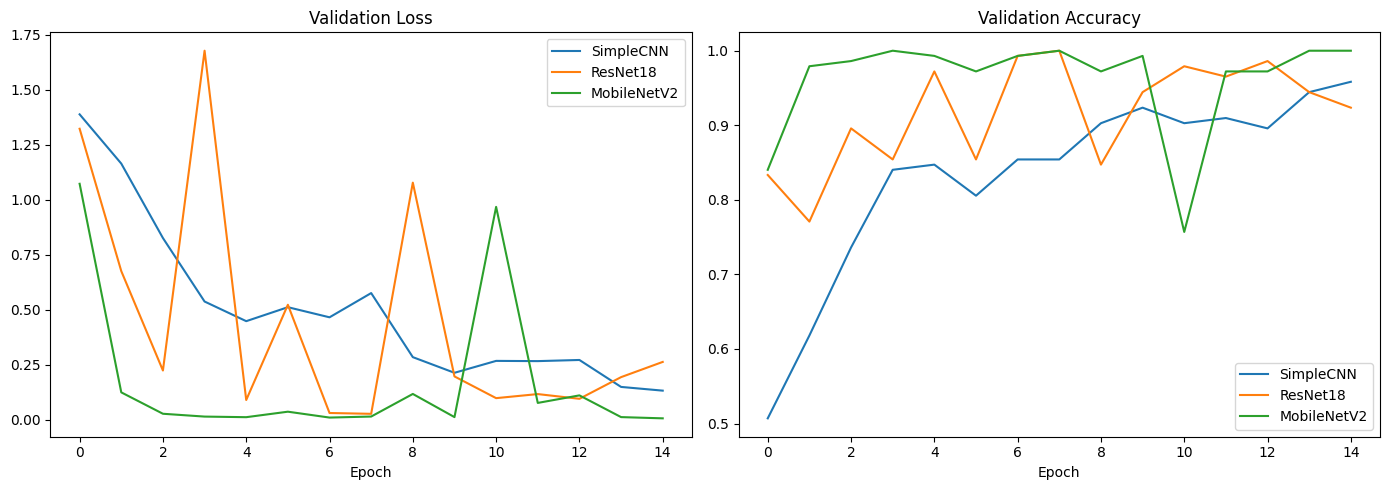

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in [('SimpleCNN', cnn_history), ('ResNet18', resnet_history), ('MobileNetV2', mobilenet_history)]:
    axes[0].plot(history['val_loss'], label=name)
    axes[1].plot(history['val_acc'], label=name)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
comparison = pd.DataFrame({
    'Model': ['SimpleCNN', 'ResNet18', 'MobileNetV2'],
    'Val Loss': [cnn_history['val_loss'][-1], resnet_history['val_loss'][-1], mobilenet_history['val_loss'][-1]],
    'Val Acc': [cnn_history['val_acc'][-1], resnet_history['val_acc'][-1], mobilenet_history['val_acc'][-1]],
})
print(comparison.to_string(index=False))

      Model  Val Loss  Val Acc
  SimpleCNN  0.132959 0.958333
   ResNet18  0.263500 0.923611
MobileNetV2  0.007092 1.000000


### Выводы

- SimpleCNN — ожидаемо слабее transfer learning
- ResNet18 и MobileNetV2 показывают сопоставимые результаты
- Финальная модель выбирается по best validation accuracy на тесте
- MobileNetV2 значительно легче EfficientNet-B0 (3.5M vs 5.3M параметров)